# Analyse stratégique des données — AfriMarket

**Contexte** : AfriMarket est une plateforme e-commerce panafricaine (Électronique, Mode, Beauté, Maison).
La direction observe des variations de CA, un taux de retour préoccupant, des dépenses marketing élevées
et des écarts de performance entre villes. Cette analyse porte sur 6 mois d'activité commerciale.

**Objectif** : produire une analyse fiable (après audit et nettoyage des données) permettant de répondre
à 4 questions stratégiques : quelle catégorie prioriser, où investir géographiquement, quel canal marketing
mérite plus de budget, comment améliorer la rétention client.

**Plan** :
1. Audit & compréhension des données
2. Data cleaning
3. Feature engineering
4. Analyses (performance globale, catégorie, géographie, marketing, clients)
5. Recommandations stratégiques
6. Conclusion business orientée action


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px

from afrimarket import analysis, pipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
%matplotlib inline


## 1. Audit & compréhension des données\n\nAvant toute correction, on caractérise l'état brut du dataset : structure, types, doublons, valeurs manquantes et aberrantes.

In [2]:
df_raw = pipeline.load_raw()
print(f"Lignes : {df_raw.shape[0]}  |  Colonnes : {df_raw.shape[1]}")
df_raw.dtypes

Lignes : 10100  |  Colonnes : 14


id_commande             str
date_commande           str
id_client               str
ville                   str
categorie               str
nom_produit             str
prix_unitaire       float64
quantite              int64
remise              float64
cout_livraison      float64
methode_paiement        str
canal_marketing         str
cout_marketing      float64
statut_commande         str
dtype: object

In [3]:
audit = pipeline.audit_report(df_raw)
for cle in ["doublons_lignes_completes", "doublons_id_commande", "remises_negatives",
            "prix_negatifs", "quantites_nulles", "prix_outliers_iqr"]:
    print(f"{cle:30s} : {audit[cle]}")
print()
print("Villes brutes         :", audit["villes_uniques_brutes"])
print("Catégories brutes     :", audit["categories_uniques_brutes"])
print("Statuts bruts         :", audit["statuts_uniques_bruts"])

doublons_lignes_completes      : 100
doublons_id_commande           : 100
remises_negatives              : 614
prix_negatifs                  : 632
quantites_nulles               : 608
prix_outliers_iqr              : 799

Villes brutes         : ['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Kinshassa', 'Libreville', 'Lomé']
Catégories brutes     : ['Beauté', 'Maison', 'Mode', 'electronique', 'Électronique']
Statuts bruts         : ['Annulée', 'Livrée', 'retournée']


### Synthèse de l'audit — problèmes détectés

Sur **10 100 commandes brutes**, les problèmes de qualité suivants ont été identifiés :

- **Doublons** : 100 commandes strictement dupliquées (même `id_commande`) → à dédupliquer.
- **Villes mal orthographiées** : `Kinshassa` en doublon de `Kinshasa` (faute de frappe).
- **Catégories incohérentes** : `electronique` (minuscule, sans accent) coexiste avec `Électronique`.
- **Statuts incohérents en casse** : `retournée` (minuscule) à côté de `Annulée` / `Livrée`.
- **Remises négatives** : 614 lignes avec une remise `< 0` (erreur de saisie, impossible commercialement).
- **Prix aberrants** : 632 lignes avec un `prix_unitaire` négatif, et 799 valeurs extrêmes détectées par
  la méthode IQR (probables erreurs de saisie ou promotions mal enregistrées).
- **Quantités nulles** : 608 lignes avec `quantite = 0`, donc sans vente réelle associée.
- **Aucune valeur manquante (NaN)** détectée sur les colonnes — la donnée est présente mais parfois invalide.

Ces anomalies, si elles ne sont pas corrigées, biaiseraient fortement le CA, les marges et les taux calculés
(ex. surestimation du taux de retour à cause de la casse, sous-estimation du CA à cause des remises négatives).


## 2. Data Cleaning\n\nRègles de nettoyage appliquées pour produire `df_clean` (voir `src/afrimarket/pipeline.py::clean_data`) :

In [4]:
df_clean = pipeline.clean_data(df_raw)
print(f"Avant nettoyage : {len(df_raw)} lignes")
print(f"Après nettoyage : {len(df_clean)} lignes  ({len(df_raw) - len(df_clean)} lignes supprimées)")
print()
print("Villes après nettoyage      :", sorted(df_clean['ville'].unique()))
print("Catégories après nettoyage  :", sorted(df_clean['categorie'].unique()))
print("Statuts après nettoyage     :", sorted(df_clean['statut_commande'].unique()))
print("Remises min/max              :", df_clean['remise'].min(), "/", df_clean['remise'].max())
print("Prix unitaire min/max        :", round(df_clean['prix_unitaire'].min(),2), "/", round(df_clean['prix_unitaire'].max(),2))

Avant nettoyage : 10100 lignes
Après nettoyage : 9400 lignes  (700 lignes supprimées)

Villes après nettoyage      : ['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Libreville', 'Lomé']
Catégories après nettoyage  : ['Beauté', 'Maison', 'Mode', 'Électronique']
Statuts après nettoyage     : ['Annulée', 'Livrée', 'Retournée']
Remises min/max              : 0.0 / 0.3
Prix unitaire min/max        : 3.3 / 744.48


**Règles appliquées :**

1. **Dates** standardisées en `datetime` (`date_commande`).
2. **Doublons** supprimés : lignes strictement identiques, puis doublons sur `id_commande` (on garde la 1ère occurrence).
3. **Villes** uniformisées via dictionnaire de correspondance (`Kinshassa` → `Kinshasa`).
4. **Catégories** uniformisées (casse/accents) → `Électronique`, `Mode`, `Beauté`, `Maison`.
5. **Statuts** uniformisés → `Livrée`, `Annulée`, `Retournée`.
6. **Remises négatives** : converties en valeur absolue puis plafonnées à 90% (une remise ne peut dépasser le prix).
7. **Prix aberrants** : les prix négatifs sont traités comme manquants puis imputés par la **médiane de la catégorie** ;
   les valeurs extrêmes restantes sont plafonnées par catégorie selon la méthode **IQR** (borne haute = Q3 + 1.5×IQR).
8. **Quantités nulles** : lignes supprimées (aucune vente réelle, on ne peut pas deviner l'intention d'achat).
9. **Coûts** (`cout_marketing`, `cout_livraison`) forcés en numérique, valeurs non convertibles → 0.

Le dataset propre (`df_clean`) conserve **9400 commandes exploitables** sur les 10 100 initiales.


## 3. Feature Engineering\n\nCréation des variables business nécessaires à l'analyse.

In [5]:
df = pipeline.feature_engineering(df_clean)
nouvelles_colonnes = ["chiffre_affaires", "marge_brute", "profit_net", "mois",
                       "indicateur_retour", "nombre_commandes_par_client", "valeur_vie_client"]
df[nouvelles_colonnes].head()

,chiffre_affaires,marge_brute,profit_net,mois,indicateur_retour,nombre_commandes_par_client,valeur_vie_client
0,138.72,48.55,45.10,2025-12,0,25,"8,995.65"
1,66.92,23.42,8.49,2025-07,0,4,562.86
2,977.47,342.12,336.41,2025-11,0,26,"9,474.86"
3,192.16,67.26,53.18,2025-10,0,17,"4,991.14"
4,62.21,21.77,8.95,2025-07,0,16,"3,513.12"


**Hypothèse business documentée** : le dataset ne fournit pas de coût d'achat produit (coût matière).
On retient donc une **marge brute forfaitaire de 35% du chiffre d'affaires**, hypothèse usuelle pour un
e-commerce généraliste multi-catégories — à ajuster si la direction communique un coût réel par catégorie.

- `chiffre_affaires` = prix_unitaire × quantité × (1 − remise)
- `marge_brute` = chiffre_affaires × 35%
- `profit_net` = marge_brute − coût_livraison − coût_marketing
- `mois` = mois calendaire de la commande
- `indicateur_retour` = 1 si la commande est retournée, sinon 0
- `nombre_commandes_par_client` = nombre de commandes distinctes du client
- `valeur_vie_client` (CLV simplifiée) = somme du CA généré par le client sur la période


## 4. Analyses

**Convention retenue** : le CA et le profit ne sont comptabilisés que sur les commandes **non annulées**
(une commande annulée ne génère aucune vente réelle). Le taux de retour se calcule sur les commandes
**effectivement expédiées** (`Livrée` + `Retournée`), une commande annulée n'ayant jamais été livrée.

### 4.1 Performance globale

In [6]:
perf = analysis.performance_globale(df)
pd.Series({
    "CA total ($)": round(perf["ca_total"], 2),
    "Profit net estimé ($)": round(perf["profit_net_total"], 2),
    "Panier moyen ($)": round(perf["panier_moyen"], 2),
    "Taux d'annulation": f"{perf['taux_annulation']*100:.2f} %",
    "Taux de retour": f"{perf['taux_retour']*100:.2f} %",
    "Nombre de commandes": perf["n_commandes"],
})

CA total ($)            2,506,372.77
Profit net estimé ($)     753,611.89
Panier moyen ($)              271.93
Taux d'annulation             1.95 %
Taux de retour                8.30 %
Nombre de commandes             9400
dtype: object

**Lecture** : sur 6 mois, AfriMarket génère **2,51 M$ de CA** pour un **profit net estimé de 754 k$**
(soit une marge nette d'environ 30% du CA, une fois déduits coûts logistiques et marketing du CA facturé
non annulé). Le taux d'annulation reste faible (1,9%), mais le **taux de retour à 8,3%** est un point de
vigilance qui pèse directement sur la rentabilité (coûts de traitement, remboursement, logistique retour).


### 4.2 Analyse par catégorie\n\n**Question stratégique : quelle catégorie doit être priorisée ou optimisée ?**

In [7]:
res_cat = analysis.analyse_categorie(df)
res_cat["synthese"]

,categorie,ca,marge,profit,n_commandes,taux_retour
0,Électronique,"1,869,633.07","654,371.58","614,993.38",2950,0.14
1,Maison,"374,426.74","131,049.36","107,480.89",1758,0.05
2,Mode,"185,941.97","65,079.69","27,820.06",2783,0.08
3,Beauté,"76,370.98","26,729.84","3,317.56",1726,0.03


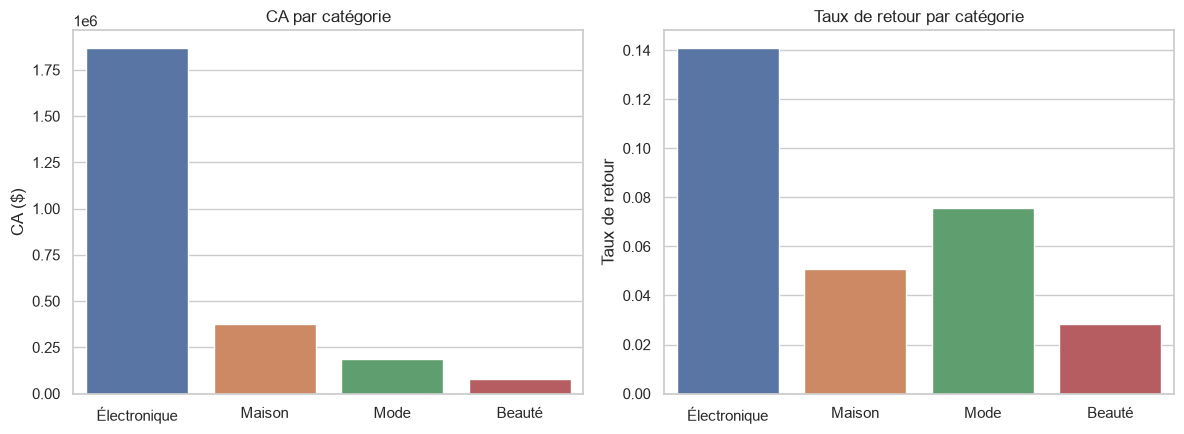

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=res_cat["synthese"], x="categorie", y="ca", hue="categorie", legend=False, ax=axes[0])
axes[0].set_title("CA par catégorie"); axes[0].set_xlabel(""); axes[0].set_ylabel("CA ($)")
sns.barplot(data=res_cat["synthese"], x="categorie", y="taux_retour", hue="categorie", legend=False, ax=axes[1])
axes[1].set_title("Taux de retour par catégorie"); axes[1].set_xlabel(""); axes[1].set_ylabel("Taux de retour")
plt.tight_layout(); plt.show()

In [9]:
fig = px.line(res_cat["evolution_mensuelle"], x="mois", y="chiffre_affaires", color="categorie",
              markers=True, title="Évolution mensuelle du CA par catégorie")
fig.show()

**Réponse à la question stratégique** :

- **Électronique** représente **74,6% du CA total** (1,87 M$) et **82% du profit net** (615 k$) : c'est le
  moteur de croissance de l'entreprise, à **prioriser en investissement** (référencement, stock, publicité).
  Revers : son taux de retour (**14,1%**) est près de 2× la moyenne globale — il doit être **optimisé**
  (fiches produits plus précises, contrôle qualité fournisseurs) pour ne pas éroder cette rentabilité.
- **Mode** et **Beauté** ont un profit quasi nul par rapport à leur marge brute théorique : les coûts de
  livraison et marketing absorbent respectivement **57%** et **88%** de leur marge brute (contre 6% pour
  l'Électronique). Leur panier moyen trop faible ne couvre pas le coût fixe par commande : ces catégories
  doivent être **optimisées économiquement** (seuil de livraison gratuite, bundles) plutôt que davantage
  poussées en l'état.


### 4.3 Analyse géographique\n\n**Question stratégique : où devons-nous investir davantage ?**

In [10]:
res_geo = analysis.analyse_geographique(df)
res_geo["synthese"]

,ville,ca,profit,n_commandes,taux_annulation
0,Kinshasa,"752,006.69","226,865.29",2717,0.00
1,Abidjan,"500,511.20","151,431.36",1756,0.00
2,Dakar,"348,727.83","104,148.41",1346,0.00
3,Douala,"331,696.39","100,121.01",1186,0.13
4,Lomé,"184,133.68","55,213.93",682,0.00
5,Cotonou,"159,116.25","47,448.91",631,0.00
6,Libreville,"124,158.29","36,991.77",467,0.00
7,Brazzaville,"106,022.43","31,391.21",432,0.00


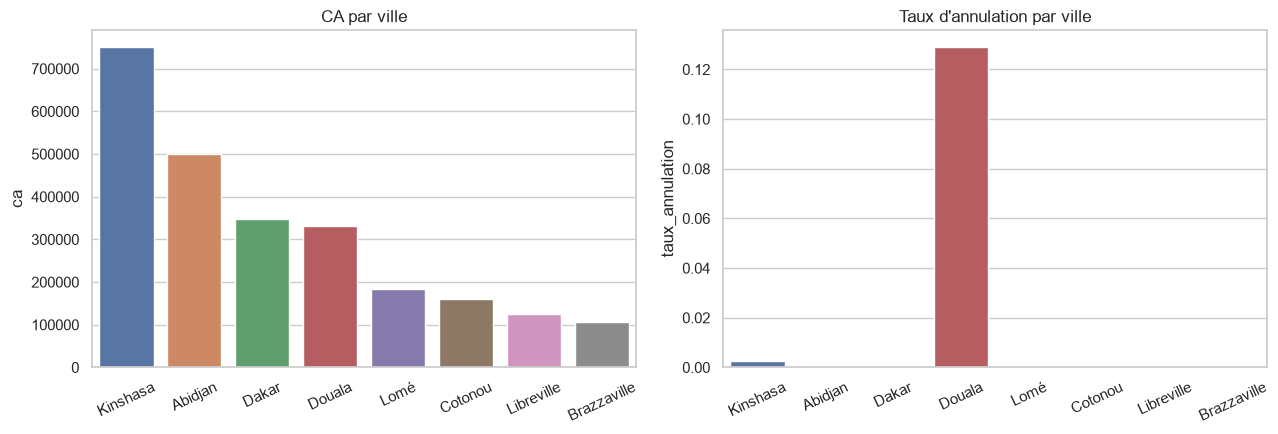

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=res_geo["synthese"], x="ville", y="ca", hue="ville", legend=False, ax=axes[0])
axes[0].set_title("CA par ville"); axes[0].set_xlabel(""); axes[0].tick_params(axis='x', rotation=25)
sns.barplot(data=res_geo["synthese"], x="ville", y="taux_annulation", hue="ville", legend=False, ax=axes[1])
axes[1].set_title("Taux d'annulation par ville"); axes[1].set_xlabel(""); axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

In [12]:
fig = px.line(res_geo["evolution_mensuelle"], x="mois", y="chiffre_affaires", color="ville",
              markers=True, title="Évolution mensuelle du CA par ville")
fig.show()

**Réponse à la question stratégique** :

- **Kinshasa** est la ville la plus performante (752 k$ de CA, 227 k$ de profit) avec un taux d'annulation
  quasi nul (0,26%) : c'est un marché mature et sain, **prioritaire pour renforcer l'investissement**
  (marketing, capacité logistique).
- **Douala** présente une **anomalie opérationnelle majeure** : un taux d'annulation de **12,9%**, contre
  moins de 1% dans toutes les autres villes. Avant d'investir davantage dans cette ville, il est indispensable
  d'**auditer la cause racine** (méthode de paiement locale, rupture de stock, fiabilité du livreur partenaire).
- **Abidjan** et **Dakar** combinent bon CA et annulation quasi nulle : marchés secondaires à consolider.


### 4.4 Analyse marketing\n\n**Question stratégique : quel canal mérite plus de budget ? Lequel doit être optimisé ou réduit ?**

In [13]:
res_mkt = analysis.analyse_marketing(df)
res_mkt["synthese"]

,canal_marketing,ca,cout_marketing,n_commandes,n_clients,roi,taux_retention
0,Email,"531,796.95","2,296.67",1852,895,230.55,0.45
1,Google Ads,"664,878.17","12,935.32",2351,991,50.40,0.50
3,Instagram Ads,"949,555.17","37,032.07",3699,1227,24.64,0.54
2,Influenceur,"360,142.48","15,984.23",1315,742,21.53,0.42


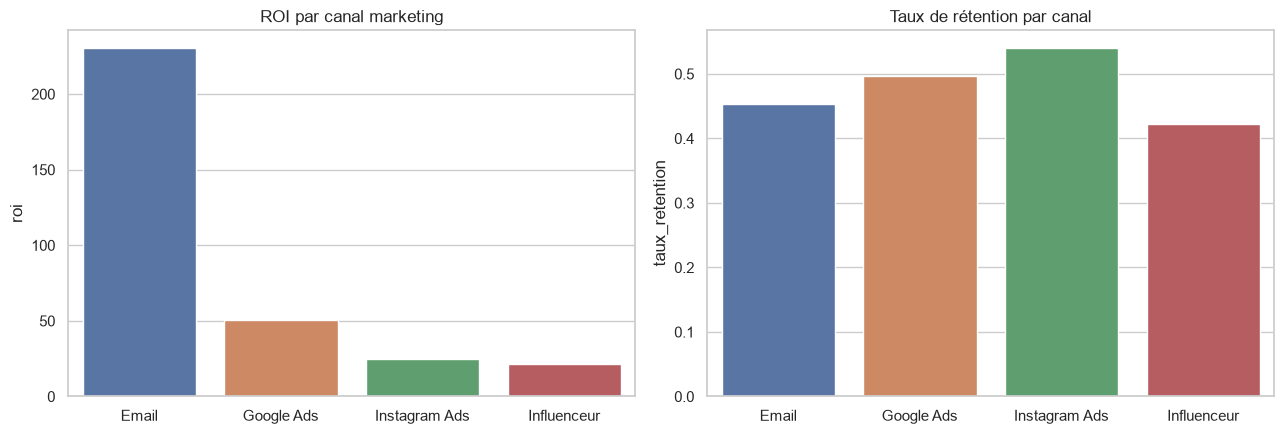

In [14]:
order = res_mkt["synthese"].sort_values("roi", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=order, x="canal_marketing", y="roi", hue="canal_marketing", legend=False, ax=axes[0])
axes[0].set_title("ROI par canal marketing"); axes[0].set_xlabel("")
sns.barplot(data=order, x="canal_marketing", y="taux_retention", hue="canal_marketing", legend=False, ax=axes[1])
axes[1].set_title("Taux de rétention par canal"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

**Réponse à la question stratégique** (ROI = (Revenus − Coût marketing) / Coût marketing) :

- **Email** affiche le meilleur ROI de très loin (**230**) pour un budget marginal (2 297 $, le plus petit
  budget des 4 canaux) : c'est un canal **sous-financé** au regard de son efficacité — **augmenter son budget**
  est la priorité n°1, avec un potentiel de rendement élevé même en cas de rendements décroissants.
- **Google Ads** (ROI 50) reste solide et scalable : à maintenir/renforcer modérément.
- **Instagram Ads** génère le plus de CA en volume (950 k$) et la meilleure rétention (54%), mais avec un
  ROI plus faible (25) car son budget est le plus élevé (37 k$) : canal à **conserver pour le volume et la
  fidélisation**, mais à optimiser (ciblage, créatifs) plutôt qu'à augmenter en budget brut.
- **Influenceur** cumule le **pire ROI (21,5)** et la **pire rétention (42%)** pour un budget conséquent
  (16 k$) : c'est le canal à **réduire ou réattribuer en priorité** vers Email et Google Ads.


### 4.5 Analyse clients\n\n**Question stratégique : comment améliorer la rétention ?**

In [15]:
res_cli = analysis.analyse_clients(df)
print(f"Nombre total de clients      : {res_cli['n_clients_total']}")
print(f"% de clients récurrents      : {res_cli['pct_clients_recurrents']*100:.1f} %")
print(f"Clients générant 80% du CA   : {res_cli['n_clients_pour_80pct_ca']} ({res_cli['part_clients_pour_80pct_ca']*100:.1f} % de la base)")
res_cli["top10_clients"]

Nombre total de clients      : 1734
% de clients récurrents      : 73.2 %
Clients générant 80% du CA   : 553 (31.9 % de la base)


,id_client,ca_total_client
0,C0157,"11,552.30"
1,C0266,"10,673.23"
2,C0120,"9,514.34"
3,C0003,"9,474.86"
4,C0051,"9,419.49"
5,C0379,"8,995.65"
6,C0114,"8,918.52"
7,C0067,"8,476.41"
8,C0184,"8,474.63"
9,C0364,"8,252.47"


In [16]:
res_cli["segmentation"]

,segment,n_clients,ca_total
0,Bronze,434,"36,194.42"
1,Argent,433,"158,368.02"
2,Or,433,"501,204.42"
3,Platine,434,"1,810,605.91"


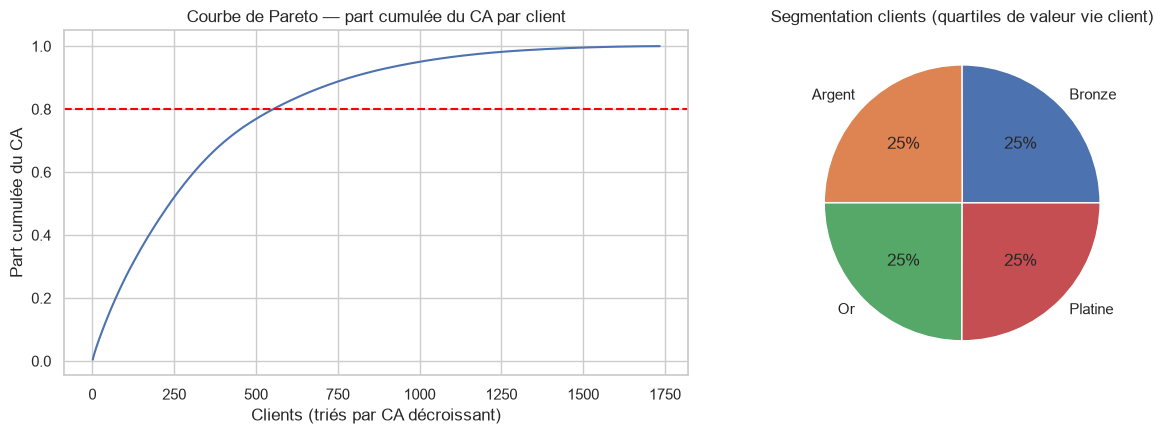

In [17]:
clv_sorted = res_cli["clv_par_client"].sort_values("valeur_vie_client", ascending=False).reset_index(drop=True)
clv_sorted["rang"] = clv_sorted.index + 1
clv_sorted["part_cumulee_ca"] = clv_sorted["valeur_vie_client"].cumsum() / clv_sorted["valeur_vie_client"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(clv_sorted["rang"], clv_sorted["part_cumulee_ca"])
axes[0].axhline(0.8, color="red", linestyle="--")
axes[0].set_title("Courbe de Pareto — part cumulée du CA par client")
axes[0].set_xlabel("Clients (triés par CA décroissant)"); axes[0].set_ylabel("Part cumulée du CA")
axes[1].pie(res_cli["segmentation"]["n_clients"], labels=res_cli["segmentation"]["segment"], autopct="%1.0f%%")
axes[1].set_title("Segmentation clients (quartiles de valeur vie client)")
plt.tight_layout(); plt.show()

**Réponse à la question stratégique** :

- La base compte **1 734 clients**, dont **73,2% sont récurrents** (≥ 2 commandes) : c'est un signal de
  fidélité globalement sain.
- L'analyse Pareto montre que **31,9% des clients génèrent 80% du CA** — une concentration plus modérée
  qu'un Pareto classique (20/80), ce qui est plutôt positif (le CA ne dépend pas d'une poignée de clients).
- La segmentation par quartiles de valeur vie client montre une **forte polarisation** : le segment
  **Platine** (434 clients, 25% de la base) génère **1,81 M$, soit 72% du CA total**, tandis que le segment
  **Bronze** (434 clients) ne génère que 36 k$ (1,4% du CA).
- **Pour améliorer la rétention** : (1) programme de fidélisation ciblé sur Bronze/Argent (867 clients,
  seulement 7,8% du CA cumulé) pour les faire progresser en gamme ; (2) traitement VIP pour Platine
  (sécuriser le cœur du revenu, ex. avantages exclusifs, service prioritaire).


## 5. Recommandations stratégiques

1. **Prioriser l'Électronique tout en réduisant son taux de retour.** Cette catégorie porte 74,6% du CA
   et 82% du profit ; chaque point de taux de retour gagné (actuellement 14,1%, presque 2× la moyenne) se
   traduit directement en profit préservé. Actions : fiches produits plus précises, contrôle qualité
   fournisseurs, politique de retour resserrée sur les motifs évitables.

2. **Revoir l'économie unitaire de Mode et Beauté.** Leurs coûts logistiques/marketing consomment 57% et
   88% de leur marge brute (contre 6% pour l'Électronique) : panier moyen trop faible pour couvrir le coût
   fixe par commande. Actions : seuil de livraison gratuite au-delà d'un montant minimum, bundles produits,
   renégociation des frais de livraison pour ces catégories.

3. **Auditer en urgence l'anomalie opérationnelle de Douala** (12,9% d'annulation vs < 1% ailleurs) avant
   d'y engager davantage de budget marketing. Suspects à vérifier en priorité : méthode de paiement locale,
   ruptures de stock, fiabilité du livreur partenaire.

4. **Réallouer le budget marketing vers l'efficacité.** Augmenter le budget Email (ROI 230, aujourd'hui
   sous-financé à 2 297 $) et maintenir Google Ads (ROI 50) ; réduire ou requalifier le budget Influenceur
   (pire ROI à 21,5 et pire rétention à 42%) vers ces deux canaux plus performants.

5. **Structurer un programme de fidélisation par segment.** VIP pour le segment Platine (72% du CA, à
   sécuriser en priorité) et offres d'activation pour Bronze/Argent (867 clients, 7,8% du CA seulement) afin
   de les faire progresser en valeur — la base est déjà fidèle (73,2% de clients récurrents), il s'agit
   surtout d'accélérer la montée en gamme.

## 6. Conclusion business orientée action

AfriMarket dispose d'un socle commercial sain : 2,51 M$ de CA sur 6 mois, 754 k$ de profit net estimé, une
base client majoritairement fidèle (73,2% de récurrence) et un taux d'annulation globalement faible (1,9%).
Trois leviers d'action immédiats se dégagent : **(1)** consolider l'Électronique en maîtrisant ses retours,
**(2)** corriger la rentabilité structurelle de Mode et Beauté par le panier moyen plutôt que par le volume,
et **(3)** traiter sans délai l'anomalie opérationnelle de Douala qui grève silencieusement la performance
géographique. Sur le plan marketing, un simple réarbitrage de budget — moins d'Influenceur, plus d'Email et
de Google Ads — peut améliorer le ROI global sans augmenter la dépense totale. Enfin, la fidélisation doit
devenir différenciée par segment plutôt qu'uniforme, pour sécuriser le cœur de revenu (segment Platine) tout
en développant la base moins engagée. Ces actions sont directement pilotables dans le dashboard Streamlit
livré avec cette analyse, qui permet un suivi mensuel de chacun de ces indicateurs.
